# Data Preparation

# Imports

In [19]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully!")
print(f"Scikit-learn version: {sklearn.__version__}")

All libraries loaded successfully!
Scikit-learn version: 1.8.0


# Setting the threshold for 3 class labelling

In [20]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Set this to wherever your Net1_CMH folder is
BASE_PATH = Path(r"C:\Users\Hp\water_leakage_ml\data\Net1_CMH\Net1_CMH")

# Thresholds for 3-class labelling
MINOR_MAX_DIAMETER = 0.111  # metres — below this = minor leak

# Function to load one scenario


In [21]:
def load_scenario(scenario_path):
    scenario_path = Path(scenario_path)
    scenario_name = scenario_path.name

    # ── 1. Load timestamps ──────────────────────────────────────
    ts_file = scenario_path / "Timestamps.csv"
    timestamps = pd.read_csv(ts_file, header=0)
    timestamps.columns = ["Index", "Timestamp"]

    # ── 2. Load labels (binary) ─────────────────────────────────
    labels_file = scenario_path / "Labels.csv"
    labels = pd.read_csv(labels_file, header=0)
    labels.columns = ["Index", "Binary_Label"]

    # ── 3. Merge timestamps + labels on Index ───────────────────
    base_df = timestamps.merge(labels, on="Index")

    # ── 4. Load leak info to get diameter ───────────────────────
    leak_diameter = None
    leaks_folder = scenario_path / "Leaks"
    if leaks_folder.exists():
        leak_info_files = list(leaks_folder.glob("*_info*"))
        if leak_info_files:
            leak_info = pd.read_csv(leak_info_files[0], header=0)
            leak_info.columns = ["Description", "Value"]
            leak_info = leak_info.set_index("Description")
            try:
                leak_diameter = float(leak_info.loc["Leak Diameter", "Value"])
            except KeyError:
                leak_diameter = None

    # ── 5. Assign 3-class label ─────────────────────────────────
    def assign_class(row):
     if row["Binary_Label"] == 0:
        return 0  # no leak
     if leak_diameter is None:
        return -1  # flag as unclassified so we can investigate
     elif leak_diameter < MINOR_MAX_DIAMETER:
        return 1  # minor leak
     else:
        return 2  # major burst

    # ── 6. Load pressure CSVs ───────────────────────────────────
    pressure_dfs = []
    for f in sorted((scenario_path / "Pressures").glob("*.csv")):
        link_id = f.stem  # e.g. "Link_9"
        df = pd.read_csv(f, header=0)
        df.columns = ["Index", f"Pressure_{link_id}"]
        pressure_dfs.append(df)

    # ── 7. Load flow CSVs ───────────────────────────────────────
    flow_dfs = []
    for f in sorted((scenario_path / "Flows").glob("*.csv")):
        link_id = f.stem
        df = pd.read_csv(f, header=0)
        df.columns = ["Index", f"Flow_{link_id}"]
        flow_dfs.append(df)

    # ── 8. Merge all pressure and flow into base_df ─────────────
    for df in pressure_dfs + flow_dfs:
        base_df = base_df.merge(df, on="Index", how="left")

    # ── 9. Add scenario identifier ──────────────────────────────
    base_df["Scenario"] = scenario_name

    return base_df

# Loop through all scenarios and combine to create a master dataset


In [26]:
all_scenarios = []
scenario_folders = sorted([
    f for f in BASE_PATH.iterdir()
    if f.is_dir() and f.name.startswith("Scenario")
])

print(f"Found {len(scenario_folders)} scenarios")

for i, scenario_path in enumerate(scenario_folders):
    try:
        df = load_scenario(scenario_path)
        all_scenarios.append(df)
        if (i + 1) % 100 == 0:
            print(f"  Loaded {i + 1} scenarios...")
    except Exception as e:
        print(f"  Skipped {scenario_path.name}: {e}")

master_df = pd.concat(all_scenarios, ignore_index=True)
print(f"\nMaster DataFrame shape: {master_df.shape}")
print(master_df["Label"].value_counts())

Found 1000 scenarios
  Loaded 100 scenarios...
  Loaded 200 scenarios...
  Loaded 300 scenarios...
  Loaded 400 scenarios...
  Loaded 500 scenarios...
  Loaded 600 scenarios...
  Loaded 700 scenarios...
  Loaded 800 scenarios...
  Loaded 900 scenarios...
  Loaded 1000 scenarios...

Master DataFrame shape: (17520000, 28)


KeyError: 'Label'

In [27]:
print(master_df.columns.tolist())

['Index', 'Timestamp', 'Binary_Label', 'Pressure_Node_10', 'Pressure_Node_11', 'Pressure_Node_12', 'Pressure_Node_13', 'Pressure_Node_2', 'Pressure_Node_21', 'Pressure_Node_22', 'Pressure_Node_23', 'Pressure_Node_31', 'Pressure_Node_32', 'Pressure_Node_9', 'Flow_Link_10', 'Flow_Link_11', 'Flow_Link_110', 'Flow_Link_111', 'Flow_Link_112', 'Flow_Link_113', 'Flow_Link_12', 'Flow_Link_121', 'Flow_Link_122', 'Flow_Link_21', 'Flow_Link_22', 'Flow_Link_31', 'Flow_Link_9', 'Scenario']


# Diameter lookup per scenario

In [28]:
# Step 1 — Build a diameter lookup dictionary per scenario
scenario_diameters = {}

for scenario_path in scenario_folders:
    leaks_folder = scenario_path / "Leaks"
    if leaks_folder.exists():
        leak_info_files = list(leaks_folder.glob("*_info*"))
        if leak_info_files:
            try:
                leak_info = pd.read_csv(leak_info_files[0], header=None)
                leak_info.columns = ["Description", "Value"]
                leak_info["Description"] = leak_info["Description"].str.strip()
                leak_info["Value"] = leak_info["Value"].astype(str).str.strip()
                leak_info = leak_info.set_index("Description")
                diameter = float(leak_info.loc["Leak Diameter", "Value"])
                scenario_diameters[scenario_path.name] = diameter
            except Exception:
                scenario_diameters[scenario_path.name] = None
        else:
            scenario_diameters[scenario_path.name] = None
    else:
        scenario_diameters[scenario_path.name] = None

print(f"Scenarios with valid diameter: {sum(v is not None for v in scenario_diameters.values())}")
print(f"Scenarios with None diameter:  {sum(v is None for v in scenario_diameters.values())}")

Scenarios with valid diameter: 741
Scenarios with None diameter:  259


# Mapping diameter to class label

In [29]:
# Step 2 — Map diameter to each row via Scenario column
master_df["Diameter"] = master_df["Scenario"].map(scenario_diameters)

# Step 3 — Assign 3-class label
def assign_label(row):
    if row["Binary_Label"] == 0:
        return 0
    elif row["Diameter"] is None or pd.isna(row["Diameter"]):
        return -1  # unclassified
    elif row["Diameter"] < MINOR_MAX_DIAMETER:
        return 1
    else:
        return 2

master_df["Label"] = master_df.apply(assign_label, axis=1)

# Step 4 — Check distribution
print("\nClass distribution:")
print(master_df["Label"].value_counts().sort_index())


Class distribution:
Label
0    13711752
1     1900959
2     1907289
Name: count, dtype: int64


In [30]:
print(master_df["Label"].value_counts().sort_index())

Label
0    13711752
1     1900959
2     1907289
Name: count, dtype: int64


In [31]:
print(master_df.head())
print("\nColumn names:", master_df.columns.tolist())
print("\nMissing values:\n", master_df.isnull().sum())
print("\nClass distribution:\n", master_df["Label"].value_counts(normalize=True).round(3))

   Index            Timestamp  Binary_Label  Pressure_Node_10  \
0      1  2017-01-01 00:00:00           0.0            92.944   
1      2  2017-01-01 00:30:00           0.0            93.525   
2      3  2017-01-01 01:00:00           0.0            94.188   
3      4  2017-01-01 01:30:00           0.0            94.841   
4      5  2017-01-01 02:00:00           0.0            95.488   

   Pressure_Node_11  Pressure_Node_12  Pressure_Node_13  Pressure_Node_2  \
0            89.658            82.317            83.756           36.576   
1            90.288            83.008            84.478           37.265   
2            91.007            83.731            85.228           37.985   
3            91.715            84.487            85.989           38.741   
4            92.417            85.252            86.766           39.505   

   Pressure_Node_21  Pressure_Node_22  ...  Flow_Link_12  Flow_Link_121  \
0            84.905            83.847  ...          14.4           25.2   
1 

# Save the master dataset

In [32]:
master_df.to_csv(BASE_PATH.parent / "master_dataset.csv", index=False)
print("Saved master_dataset.csv")

Saved master_dataset.csv


# Plot class distribution

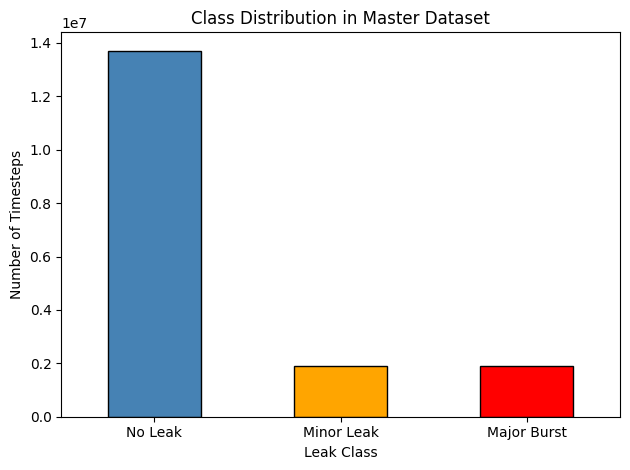

No Leak        13711752
Minor Leak      1900959
Major Burst     1907289
Name: count, dtype: int64

Total timesteps: 17,520,000


In [33]:
import matplotlib.pyplot as plt

label_counts = master_df["Label"].value_counts().sort_index()
label_names = {0: "No Leak", 1: "Minor Leak", 2: "Major Burst"}

label_counts.index = [label_names[i] for i in label_counts.index]
label_counts.plot(kind="bar", color=["steelblue", "orange", "red"], edgecolor="black")
plt.title("Class Distribution in Master Dataset")
plt.xlabel("Leak Class")
plt.ylabel("Number of Timesteps")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(label_counts)
print(f"\nTotal timesteps: {len(master_df):,}")

# Determining the optimum class threshold

Total scenarios with diameter info: 741

Diameter statistics:
count    741.000000
mean       0.108693
std        0.052114
min        0.000000
25%        0.062527
50%        0.111591
75%        0.154830
max        0.199531
dtype: float64

Percentiles:
0.25    0.062527
0.50    0.111591
0.75    0.154830
0.90    0.179025
dtype: float64


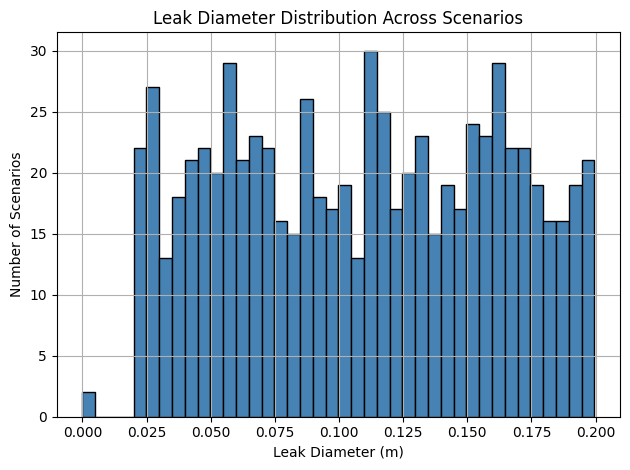

In [34]:
diameters = []
for scenario_path in scenario_folders:
    leaks_folder = scenario_path / "Leaks"
    if leaks_folder.exists():
        leak_info_files = list(leaks_folder.glob("*_info*"))
        if leak_info_files:
            try:
                leak_info = pd.read_csv(leak_info_files[0], header=None)
                leak_info.columns = ["Description", "Value"]
                leak_info["Description"] = leak_info["Description"].str.strip()
                leak_info["Value"] = leak_info["Value"].astype(str).str.strip()
                leak_info = leak_info.set_index("Description")
                diameter = float(leak_info.loc["Leak Diameter", "Value"])
                diameters.append(diameter)
            except Exception as e:
                print(f"Failed on {scenario_path.name}: {e}")

diameters = pd.Series(diameters)
print(f"Total scenarios with diameter info: {len(diameters)}")
print(f"\nDiameter statistics:")
print(diameters.describe())
print(f"\nPercentiles:")
print(diameters.quantile([0.25, 0.50, 0.75, 0.90]))

diameters.hist(bins=40, color="steelblue", edgecolor="black")
plt.title("Leak Diameter Distribution Across Scenarios")
plt.xlabel("Leak Diameter (m)")
plt.ylabel("Number of Scenarios")
plt.tight_layout()
plt.show()

In [14]:
diameters_check = []
none_count = 0

for scenario_path in scenario_folders:
    leaks_folder = scenario_path / "Leaks"
    if leaks_folder.exists():
        leak_info_files = list(leaks_folder.glob("*_info*"))
        if leak_info_files:
            try:
                leak_info = pd.read_csv(leak_info_files[0], header=None)
                leak_info.columns = ["Description", "Value"]
                leak_info["Description"] = leak_info["Description"].str.strip()
                leak_info["Value"] = leak_info["Value"].astype(str).str.strip()
                leak_info = leak_info.set_index("Description")
                diameter = float(leak_info.loc["Leak Diameter", "Value"])
                diameters_check.append(diameter)
            except Exception as e:
                none_count += 1
        else:
            none_count += 1
    else:
        none_count += 1

print(f"Scenarios with valid diameter: {len(diameters_check)}")
print(f"Scenarios where diameter is None: {none_count}")
print(f"\nDiameter value counts below 0.111m: {sum(d < 0.111 for d in diameters_check)}")
print(f"Diameter value counts above 0.111m: {sum(d >= 0.111 for d in diameters_check)}")

Scenarios with valid diameter: 741
Scenarios where diameter is None: 259

Diameter value counts below 0.111m: 369
Diameter value counts above 0.111m: 372
